# 🍽️ Cognifyz Data Analysis Internship

# Level 1 - Task 3 : Price Range Analysis

## Objective

This analysis aims to:

- Analyze the distribution of restaurants across different price ranges.
- Calculate the percentage of restaurants in each price category.
- Examine the relationship between price range and average restaurant rating.
- Present the findings using professional visualizations.

---

### Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn

In [1]:
# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("Dataset.csv")

print("Dataset Loaded Successfully")
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset Loaded Successfully
Rows : 9551
Columns : 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
# Restaurant Distribution by Price Range

price_distribution = df["Price range"].value_counts().sort_index()

price_distribution

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [3]:
# Percentage Distribution

price_percentage = (
    price_distribution / len(df)
) * 100

price_percentage.round(2)

Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64

In [4]:
# Average Rating by Price Range

average_rating = (
    df.groupby("Price range")["Aggregate rating"]
      .mean()
)

average_rating

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64

findfont: Failed to find font weight medium, now using 400.


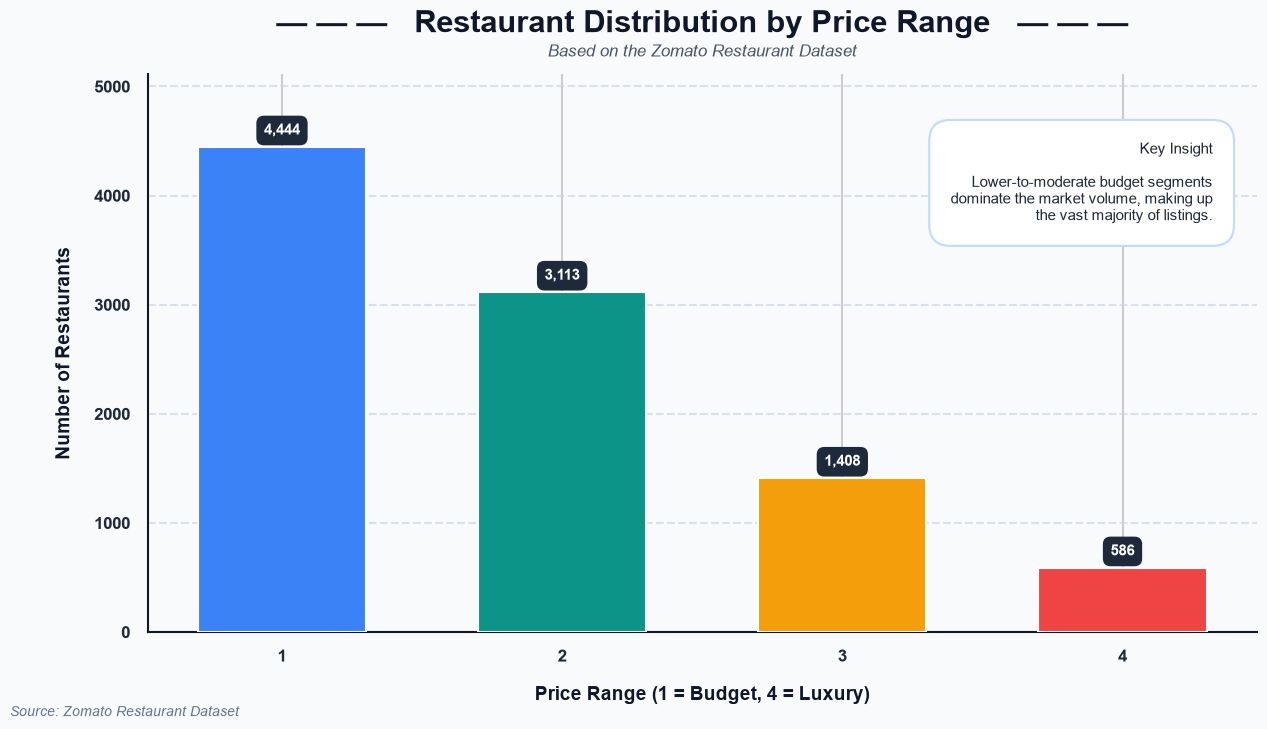

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming price_distribution is your Pandas Series
# price_distribution = pd.Series([4500, 2800, 1200, 500], index=['1', '2', '3', '4'])

# 1. Set up the figure with a clean, soft background color (#F8FAFC)
fig, ax = plt.subplots(figsize=(13, 7.5), facecolor="#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 2. Define a premium, distinct color palette for price tiers
custom_colors = [
    "#3B82F6",  # Price Range 1 (Budget / Blue)
    "#0D9488",  # Price Range 2 (Moderate / Teal)
    "#F59E0B",  # Price Range 3 (Expensive / Orange)
    "#EF4444",  # Price Range 4 (Luxury / Red)
    "#6366F1",  # Fallback color 1
    "#8B5CF6"   # Fallback color 2
]
colors = custom_colors[:len(price_distribution)]

# 3. Create the bar chart (removing harsh black outlines)
bars = ax.bar(
    price_distribution.index.astype(str),
    price_distribution.values,
    color=colors,
    width=0.6,
    zorder=3
)

# 4. Add value labels above the bars inside stylized dark pill tags
max_val = price_distribution.values.max() if len(price_distribution) > 0 else 100
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 12),  # Offset text vertically in points
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.5", 
            facecolor="#1E293B", 
            edgecolor="none", 
            lw=0
        ),
        zorder=4
    )

# 5. Header Title and Subtitle Design with accent markers
ax.text(
    0.5, 1.09, "— — —   Restaurant Distribution by Price Range   — — —",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=22, fontweight="bold", color="#0F172A"
)
ax.text(
    0.5, 1.04, "Based on the Zomato Restaurant Dataset",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=12, style="italic", color="#475569"
)

# 6. Floating "Key Insight" Panel Box
insight_text = (
    "Key Insight\n\n"
    "Lower-to-moderate budget segments\n"
    "dominate the market volume, making up\n"
    "the vast majority of listings."
)
ax.text(
    0.96, 0.88, insight_text,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=11, color="#1E293B", weight="medium",
    bbox=dict(
        boxstyle="round,pad=1.4", 
        facecolor="white", 
        edgecolor="#BFDBFE", 
        lw=1.5
    ),
    zorder=5
)

# 7. Axis Labels & Tick Styling
ax.set_xlabel("Price Range (1 = Budget, 4 = Luxury)", fontsize=14, fontweight="bold", labelpad=15, color="#0F172A")
ax.set_ylabel("Number of Restaurants", fontsize=14, fontweight="bold", labelpad=15, color="#0F172A")

plt.xticks(fontsize=12, fontweight="bold", color="#1E293B")
plt.yticks(fontsize=12, fontweight="bold", color="#1E293B")

# Dynamically pad the y-axis ceiling so pill labels don't get truncated
ax.set_ylim(0, max_val * 1.15)

# 8. Clean up chart borders (Remove top/right boundaries to match infographic)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["left"].set_color("#0F172A")
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["bottom"].set_color("#0F172A")

# 9. Soft, light gridlines rendered behind the bars
ax.grid(axis="y", linestyle="--", alpha=0.7, color="#CBD5E1", zorder=0)

# 10. Footer data source attribution
plt.text(
    0.02, 0.02, "Source: Zomato Restaurant Dataset", 
    transform=fig.transFigure, fontsize=10, style="italic", color="#64748B"
)

plt.tight_layout()
plt.show()

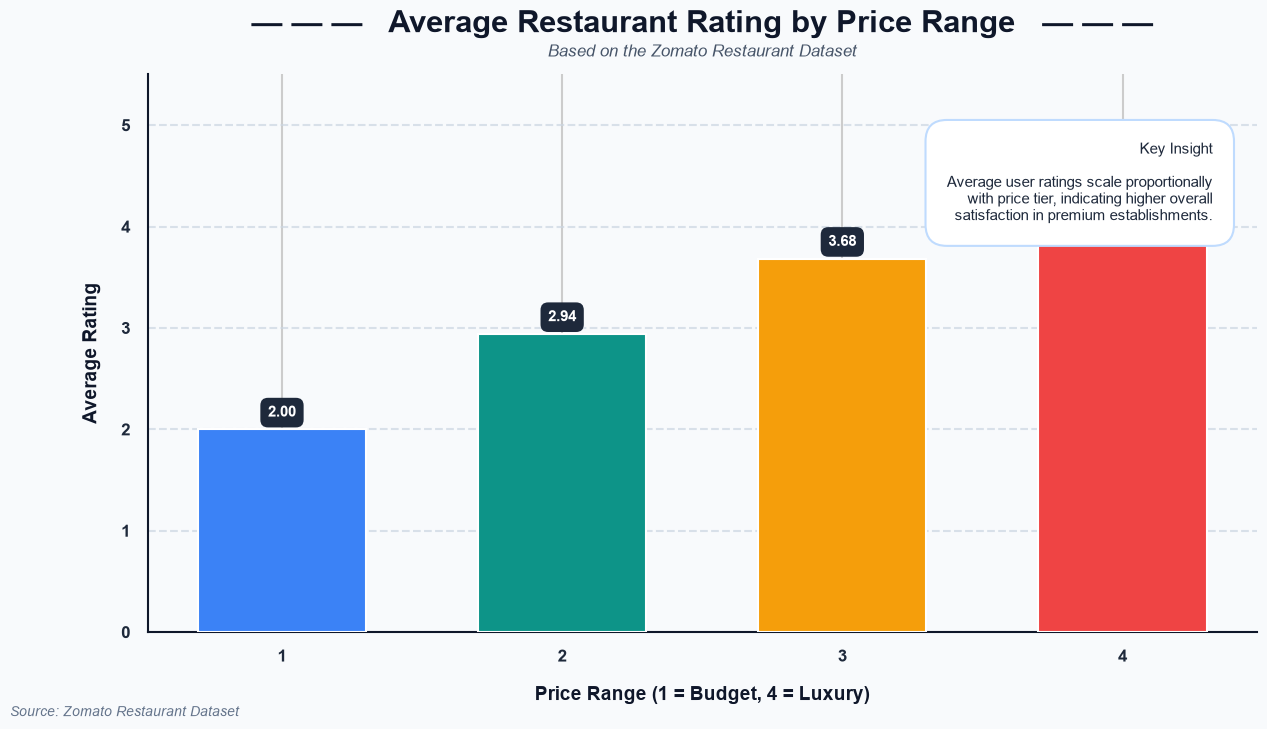

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming average_rating is your Pandas Series
# average_rating = pd.Series([3.85, 4.12, 4.35, 4.61], index=['1', '2', '3', '4'])

# 1. Set up the figure with a clean, soft background color (#F8FAFC)
fig, ax = plt.subplots(figsize=(13, 7.5), facecolor="#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 2. Define a premium, distinct color palette for the price groups
custom_colors = [
    "#3B82F6",  # Price Range 1 (Blue)
    "#0D9488",  # Price Range 2 (Teal)
    "#F59E0B",  # Price Range 3 (Orange)
    "#EF4444",  # Price Range 4 (Red)
    "#6366F1",  # Fallback color 1
    "#8B5CF6"   # Fallback color 2
]
colors = custom_colors[:len(average_rating)]

# 3. Create the bar chart (removing harsh black outlines)
bars = ax.bar(
    average_rating.index.astype(str),
    average_rating.values,
    color=colors,
    width=0.6,
    zorder=3
)

# 4. Add rating values above the bars inside stylized dark pill tags
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 12),  # Offset text vertically in points
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.5", 
            facecolor="#1E293B", 
            edgecolor="none", 
            lw=0
        ),
        zorder=4
    )

# 5. Header Title and Subtitle Design with accent markers
ax.text(
    0.5, 1.09, "— — —   Average Restaurant Rating by Price Range   — — —",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=22, fontweight="bold", color="#0F172A"
)
ax.text(
    0.5, 1.04, "Based on the Zomato Restaurant Dataset",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=12, style="italic", color="#475569"
)

# 6. Floating "Key Insight" Panel Box
insight_text = (
    "Key Insight\n\n"
    "Average user ratings scale proportionally\n"
    "with price tier, indicating higher overall\n"
    "satisfaction in premium establishments."
)
ax.text(
    0.96, 0.88, insight_text,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=11, color="#1E293B", weight="medium",
    bbox=dict(
        boxstyle="round,pad=1.4", 
        facecolor="white", 
        edgecolor="#BFDBFE", 
        lw=1.5
    ),
    zorder=5
)

# 7. Axis Labels & Tick Styling
ax.set_xlabel("Price Range (1 = Budget, 4 = Luxury)", fontsize=14, fontweight="bold", labelpad=15, color="#0F172A")
ax.set_ylabel("Average Rating", fontsize=14, fontweight="bold", labelpad=15, color="#0F172A")

plt.xticks(fontsize=12, fontweight="bold", color="#1E293B")
plt.yticks(fontsize=12, fontweight="bold", color="#1E293B")

# Set y-axis ceiling slightly above max rating (5.5) so pill tags don't clip
ax.set_ylim(0, 5.5)

# 8. Clean up chart borders (Remove top/right boundaries)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["left"].set_color("#0F172A")
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["bottom"].set_color("#0F172A")

# 9. Soft, light gridlines rendered behind the bars
ax.grid(axis="y", linestyle="--", alpha=0.7, color="#CBD5E1", zorder=0)

# 10. Footer data source attribution
plt.text(
    0.02, 0.02, "Source: Zomato Restaurant Dataset", 
    transform=fig.transFigure, fontsize=10, style="italic", color="#64748B"
)

plt.tight_layout()
plt.show()


# 📊 Key Insights

- Most restaurants belong to the lower and moderate price ranges.
- Higher price ranges generally have better average customer ratings.
- Price range appears to have a positive relationship with restaurant quality in this dataset.

# ✅ Conclusion

This analysis explored the distribution of restaurants across different price categories and compared their average customer ratings.

The results indicate that budget-friendly restaurants dominate the dataset, while restaurants in higher price ranges tend to receive better average ratings.

The visualizations provide an intuitive understanding of customer preferences and restaurant pricing patterns.